# Notebook 04 — Fairness Analysis
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Measure demographic parity, AIR, and subgroup error rates under the tuned global threshold
- Test an explicit mitigation that targets disparate approval rates across racial groups
- Quantify before/after trade-offs and document residual risks
- Produce deployment metadata for the downstream explainability and robustness notebooks

> **Label convention reminder:** `label=1` means approved. Under this convention, **wrongful denials are false negatives (FNR)**, while **false approvals are false positives (FPR)**.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import os

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, precision_score, recall_score,
    brier_score_loss
)

# calibration_curve moved to sklearn.calibration in newer sklearn versions
try:
    from sklearn.calibration import calibration_curve
except ImportError:
    from sklearn.metrics import calibration_curve

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 4)

print('Imports OK')
print(f'BASE_DIR: {BASE_DIR}')

Imports OK
BASE_DIR: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code


In [2]:
# ── Redirect any remaining stale ../outputs/ paths ───────────────────────────
import matplotlib.pyplot as _plt

# Guard: skip if already patched — prevents RecursionError on cell re-runs
if not getattr(_plt.savefig, '_is_capstone_patch', False):
    _orig_savefig = _plt.savefig

    def _patched_savefig(fname, *args, **kwargs):
        if isinstance(fname, str):
            if '../outputs/figures/' in fname:
                fname = os.path.join(FIGURES_DIR, os.path.basename(fname))
            elif '../outputs/tables/' in fname:
                fname = os.path.join(TABLES_DIR, os.path.basename(fname))
            elif '../outputs/' in fname:
                fname = os.path.join(BASE_DIR, os.path.basename(fname))
        return _orig_savefig(fname, *args, **kwargs)

    _patched_savefig._is_capstone_patch = True
    _plt.savefig = _patched_savefig
    print('Path patch applied.')
else:
    print('Path patch already active — skipping re-wrap.')

Path patch applied.


## 1. Load Artifacts

In [3]:
X_train    = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test     = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train    = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test     = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
prot_train = pd.read_parquet(os.path.join(BASE_DIR, 'prot_train.parquet'))
prot_test  = pd.read_parquet(os.path.join(BASE_DIR, 'prot_test.parquet'))

model = joblib.load(os.path.join(BASE_DIR, 'best_model.pkl'))
with open(os.path.join(BASE_DIR, 'model_meta.json')) as f:
    meta = json.load(f)

expected_cols = meta.get('feature_columns', [])
if expected_cols:
    X_test = X_test[expected_cols]
    X_train = X_train[expected_cols]
    print(f'Feature alignment OK — {len(expected_cols)} columns')

global_threshold = float(meta['threshold'])
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= global_threshold).astype(int)

print(f'Loaded: {meta["model_name"]} | global threshold={global_threshold:.3f}')
print(f'X_test: {X_test.shape}  |  approval rate (actual):    {y_test.mean():.2%}')
print(f'                          approval rate (predicted): {y_pred.mean():.2%}')

Feature alignment OK — 21 columns


Loaded: Gradient Boosting | global threshold=0.729
X_test: (1732355, 21)  |  approval rate (actual):    75.72%
                          approval rate (predicted): 87.10%


## 2. Core Fairness Metrics Functions

In [4]:
def group_fairness_metrics(y_true, y_prob, y_pred, group_series, min_n=30):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.array(y_pred)
    groups = pd.Series(group_series).fillna('Unknown').astype(str).values

    rows = []
    for g in np.unique(groups):
        mask = groups == g
        if mask.sum() < min_n:
            continue
        yt = y_true[mask]
        yp = y_prob[mask]
        yd = y_pred[mask]
        if len(np.unique(yt)) < 2:
            continue

        tp = ((yd == 1) & (yt == 1)).sum()
        fp = ((yd == 1) & (yt == 0)).sum()
        tn = ((yd == 0) & (yt == 0)).sum()
        fn = ((yd == 0) & (yt == 1)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        me = float((yd - yt).mean())
        mean_prob = float(yp.mean())

        rows.append({
            'group': g,
            'n': int(mask.sum()),
            'base_rate': round(float(yt.mean()), 4),
            'pred_rate': round(float(yd.mean()), 4),
            'mean_prob': round(mean_prob, 4),
            'AUC': round(roc_auc_score(yt, yp), 4),
            'TPR': round(float(tpr), 4),
            'FPR': round(float(fpr), 4),
            'FNR': round(float(fnr), 4),
            'Precision': round(float(ppv), 4),
            'F1': round(f1_score(yt, yd), 4),
            'Brier': round(brier_score_loss(yt, yp), 4),
            'ME': round(me, 4),
        })

    df = pd.DataFrame(rows).set_index('group')
    max_pred_rate = df['pred_rate'].max()
    df['AIR'] = (df['pred_rate'] / max_pred_rate).round(4)
    df['fails_80pct'] = df['AIR'] < 0.80
    pooled_std = float(pd.Series(y_prob).std())
    ref_prob = df['mean_prob'].max()
    df['SMD'] = ((df['mean_prob'] - ref_prob) / pooled_std).round(4)
    return df.sort_values('pred_rate', ascending=False)


def apply_threshold_policy(y_prob, groups, global_threshold, group_thresholds=None):
    groups = pd.Series(groups).fillna('Unknown').astype(str)
    thresholds = groups.map(group_thresholds or {}).fillna(global_threshold).astype(float)
    y_pred = (np.array(y_prob) >= thresholds.to_numpy()).astype(int)
    return y_pred, thresholds.to_numpy()


def find_threshold_for_target_rate(y_prob_g, target_rate, global_threshold, grid_size=300):
    current_rate = (y_prob_g >= global_threshold).mean()
    if current_rate >= target_rate:
        return float(global_threshold)

    candidate_thresholds = np.linspace(global_threshold, 0.01, grid_size)
    for thresh in candidate_thresholds:
        if (y_prob_g >= thresh).mean() >= target_rate:
            return float(thresh)
    return 0.01

## 3. Demographic Parity & 80% Rule

In [5]:
PROTECTED_COLS = [c for c in [
    'derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age'
] if c in prot_test.columns]

fairness_tables = {}

for col in PROTECTED_COLS:
    print(f'\n══ Fairness Metrics: {col} ══')
    tbl = group_fairness_metrics(y_test, y_prob, y_pred, prot_test[col])
    fairness_tables[col] = tbl
    print(tbl.to_string())

    flagged = tbl[tbl['fails_80pct']]
    if not flagged.empty:
        print(f'\n  ⚠ 80% rule FAILS for: {flagged.index.tolist()}')
    else:
        print('\n  ✓ 80% rule holds for all groups')


══ Fairness Metrics: derived_race ══


                                                 n  base_rate  pred_rate  mean_prob     AUC     TPR     FPR     FNR  Precision      F1   Brier      ME     AIR  fails_80pct     SMD
group                                                                                                                                                                              
Joint                                        37803     0.8029     0.9177     0.9015  0.8382  0.9843  0.6468  0.0157     0.8611  0.9185  0.1224  0.1149  1.0000        False  0.0000
Asian                                       104674     0.7876     0.8824     0.8811  0.8698  0.9816  0.5146  0.0184     0.8761  0.9259  0.1108  0.0948  0.9615        False -0.0933
White                                      1109449     0.7820     0.8819     0.8692  0.8386  0.9708  0.5632  0.0292     0.8608  0.9125  0.1234  0.1000  0.9610        False -0.1477
Race Not Available                          306591     0.7218     0.8598     0.8581  0.8452  0.9754 

                        n  base_rate  pred_rate  mean_prob     AUC     TPR     FPR     FNR  Precision      F1   Brier      ME     AIR  fails_80pct     SMD
group                                                                                                                                                     
Joint              601023     0.8168     0.9164     0.8976  0.8324  0.9816  0.6256  0.0184     0.8750  0.9252  0.1124  0.0996  1.0000        False  0.0000
Sex Not Available  155102     0.7327     0.8701     0.8671  0.8369  0.9757  0.5807  0.0243     0.8216  0.8920  0.1554  0.1374  0.9495        False -0.1395
Male               586704     0.7355     0.8558     0.8518  0.8377  0.9662  0.5487  0.0338     0.8304  0.8932  0.1453  0.1203  0.9339        False -0.2095
Female             389526     0.7074     0.8241     0.8239  0.8504  0.9608  0.4937  0.0392     0.8247  0.8876  0.1465  0.1167  0.8993        False -0.3371

  ✓ 80% rule holds for all groups

══ Fairness Metrics: derived_ethni

                               n  base_rate  pred_rate  mean_prob     AUC     TPR     FPR     FNR  Precision      F1   Brier      ME     AIR  fails_80pct     SMD
group                                                                                                                                                            
Joint                      44743     0.7906     0.9069     0.8928  0.8453  0.9824  0.6217  0.0176     0.8565  0.9151  0.1257  0.1162  1.0000        False  0.0000
Not Hispanic or Latino   1192230     0.7736     0.8778     0.8669  0.8414  0.9707  0.5605  0.0293     0.8555  0.9094  0.1272  0.1042  0.9679        False -0.1185
Ethnicity Not Available   283008     0.7289     0.8655     0.8621  0.8425  0.9758  0.5689  0.0242     0.8218  0.8922  0.1535  0.1366  0.9543        False -0.1404
Hispanic or Latino        211621     0.6962     0.8331     0.8348  0.8485  0.9696  0.5203  0.0304     0.8102  0.8828  0.1566  0.1369  0.9186        False -0.2653
Free Form Text Only         

            n  base_rate  pred_rate  mean_prob     AUC     TPR     FPR     FNR  Precision      F1   Brier      ME     AIR  fails_80pct     SMD
group                                                                                                                                         
8888    45568     0.8646     0.9725     0.9333  0.7402  0.9886  0.8696  0.0114     0.8789  0.9305  0.1102  0.1079  1.0000        False  0.0000
25-34  338035     0.8148     0.9156     0.9001  0.8611  0.9861  0.6053  0.0139     0.8776  0.9287  0.1084  0.1008  0.9415        False -0.1519
<25     61484     0.7995     0.9065     0.8873  0.8559  0.9858  0.5904  0.0142     0.8694  0.9240  0.1130  0.1070  0.9321        False -0.2104
35-44  411465     0.7645     0.8831     0.8742  0.8440  0.9769  0.5786  0.0231     0.8457  0.9066  0.1342  0.1186  0.9081        False -0.2703
45-54  358896     0.7320     0.8584     0.8528  0.8291  0.9684  0.5580  0.0316     0.8258  0.8914  0.1493  0.1264  0.8827        False -0.3682

### 3b. AIR · ME · SMD

| Metric | Definition | Flag threshold |
|--------|-----------|----------------|
| **AIR** | group approval rate / reference group approval rate | < 0.80 → potential ECOA violation |
| **ME** | mean(predicted − actual) per group | < −0.02 → model systematically under-predicts approval |
| **SMD** | (group mean prob − reference mean prob) / pooled std | \|SMD\| > 0.20 → meaningful disparity |

In [6]:
# derived_race, derived_sex, and derived_ethnicity with regulator-ready output.

print()

disparity_summary = []

for col in PROTECTED_COLS:
    if col not in prot_test.columns:
        continue
    tbl = fairness_tables.get(col)
    if tbl is None:
        continue

    disparity_view = tbl[['pred_rate', 'AIR', 'ME', 'SMD', 'fails_80pct']].copy()
    print(f'── {col} ──')
    print(disparity_view.to_string())

    # Flag AIR < 0.80 — EEOC threshold
    air_fails = tbl[tbl['fails_80pct']]
    if not air_fails.empty:
        print(f'\n  ⚠ AIR < 0.80 (potential fair-lending violation): {air_fails.index.tolist()}')
    else:
        print('  ✓ AIR ≥ 0.80 for all groups')

    # Flag ME: negative = model systematically under-predicts approval for group
    me_neg = tbl[tbl['ME'] < -0.02]
    if not me_neg.empty:
        print(f'  ⚠ ME < −0.02 (under-predicts approval): {me_neg.index.tolist()}')

    # Flag SMD: |SMD| > 0.20 = meaningful disparity in predicted probabilities
    smd_flagged = tbl[tbl['SMD'].abs() > 0.20]
    if not smd_flagged.empty:
        print(f'  ⚠ |SMD| > 0.20 (meaningful disparity): {smd_flagged.index.tolist()}')

    print()

    t = tbl[['pred_rate', 'AIR', 'ME', 'SMD', 'fails_80pct']].copy()
    t['attribute'] = col
    t = t.reset_index().rename(columns={'group': 'subgroup'})
    disparity_summary.append(t)

# Save consolidated table
disparity_df = pd.concat(disparity_summary, ignore_index=True)
save_path = os.path.join(TABLES_DIR, 'disparity_metrics.csv')
disparity_df.to_csv(save_path, index=False)
print(f'disparity table saved → {save_path}')
print()
print('Regulator interpretation:')
print('  AIR < 0.80  → potential ECOA / Fair Housing Act violation requiring remediation')
print('  ME < −0.02  → model systematically under-predicts approval for this group')
print('  |SMD| > 0.20 → meaningful disparity in predicted probabilities vs. reference group')



── derived_race ──
                                           pred_rate     AIR      ME     SMD  fails_80pct
group                                                                                    
Joint                                         0.9177  1.0000  0.1149  0.0000        False
Asian                                         0.8824  0.9615  0.0948 -0.0933        False
White                                         0.8819  0.9610  0.1000 -0.1477        False
Race Not Available                            0.8598  0.9369  0.1380 -0.1985        False
Black or African American                     0.8056  0.8778  0.1709 -0.4107        False
American Indian or Alaska Native              0.8015  0.8734  0.1729 -0.4290        False
2 or more minority races                      0.7931  0.8642  0.1721 -0.4327        False
Native Hawaiian or Other Pacific Islander     0.7732  0.8425  0.1589 -0.4981        False
Free Form Text Only                           0.6241  0.6801  0.2073 -0.9911    

### 3c. Race × Sex Intersectional Analysis

Per capstone guidance (slide 16): *"Check for intersectional disparities — race × sex is a
common regulatory focus in mortgage lending."*

Aggregate metrics by race alone can mask compound disadvantage. This cell computes fairness
metrics for all race × sex combinations with sufficient sample size (min n=200).

══ Race × Sex Intersectional Disparity Analysis ══



                                                         n  pred_rate     AIR      ME     SMD     FPR     FNR     AUC  fails_80pct
group                                                                                                                             
White | Joint                                       445939     0.9223  1.0000  0.0908 -0.0192  0.6329  0.0191  0.8284        False
Joint | Joint                                        35139     0.9190  0.9964  0.1144 -0.0123  0.6505  0.0158  0.8381        False
Joint | Male                                          1373     0.9126  0.9895  0.1122 -0.0197  0.6095  0.0118  0.8295        False
Asian | Joint                                        33284     0.9109  0.9876  0.0866  0.0000  0.5437  0.0109  0.8644        False
Race Not Available | Joint                           52024     0.9018  0.9778  0.1200 -0.0668  0.6069  0.0159  0.8452        False
Joint | Female                                        1136     0.8917  0.9668  0.12

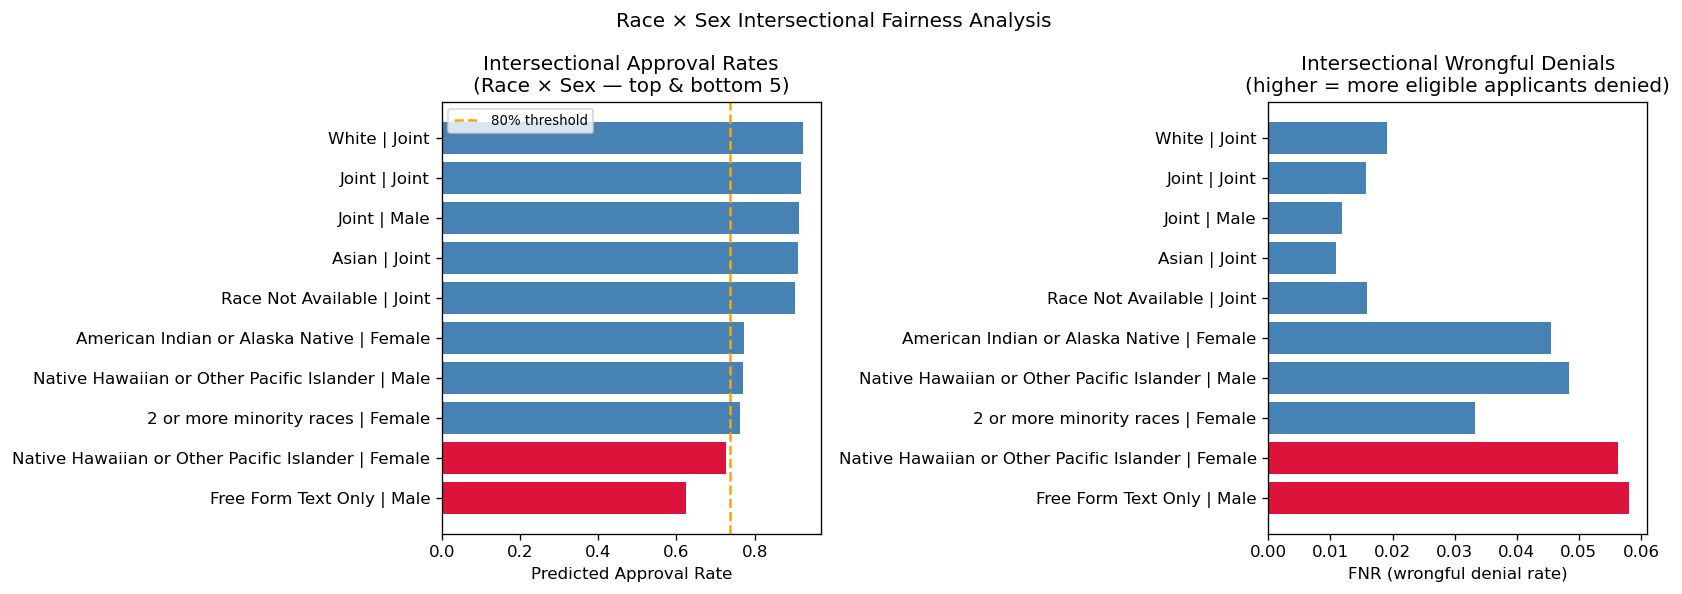

Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_intersectional_race_sex.csv


In [7]:
print('══ Race × Sex Intersectional Disparity Analysis ══')
print()

if 'derived_race' in prot_test.columns and 'derived_sex' in prot_test.columns:
    prot_test_copy = prot_test.copy()
    prot_test_copy['race_sex'] = (
        prot_test_copy['derived_race'].fillna('Unknown').astype(str) + ' | ' +
        prot_test_copy['derived_sex'].fillna('Unknown').astype(str)
    )

    intersect_tbl = group_fairness_metrics(y_test, y_prob, y_pred, prot_test_copy['race_sex'], min_n=200)
    intersect_view = intersect_tbl[['n', 'pred_rate', 'AIR', 'ME', 'SMD', 'FPR', 'FNR', 'AUC', 'fails_80pct']].copy()
    print(intersect_view.to_string())

    fails = intersect_view[intersect_view['fails_80pct']]
    print() 
    print('── Intersectional Groups Failing 80% Rule ──')
    if not fails.empty:
        print(fails[['n', 'pred_rate', 'AIR', 'FNR']].to_string())
        print()
        print('These combinations show compound disadvantage that aggregate race or sex tables can hide.')
    else:
        print('No intersectional groups fail the 80% rule at min_n=200.')

    top_bottom = pd.concat([intersect_view.head(5), intersect_view.tail(5)]).reset_index()
    colors = ['crimson' if f else 'steelblue' for f in top_bottom['fails_80pct']]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(top_bottom['group'], top_bottom['pred_rate'], color=colors)
    max_rate = intersect_view['pred_rate'].max()
    axes[0].axvline(max_rate * 0.80, color='orange', linestyle='--', linewidth=1.5, label='80% threshold')
    axes[0].set_xlabel('Predicted Approval Rate')
    axes[0].set_title('Intersectional Approval Rates\n(Race × Sex — top & bottom 5)')
    axes[0].legend(fontsize=8)
    axes[0].invert_yaxis()

    axes[1].barh(top_bottom['group'], top_bottom['FNR'], color=colors)
    axes[1].set_xlabel('FNR (wrongful denial rate)')
    axes[1].set_title('Intersectional Wrongful Denials\n(higher = more eligible applicants denied)')
    axes[1].invert_yaxis()

    plt.suptitle('Race × Sex Intersectional Fairness Analysis', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '04_intersectional_race_sex.png'), bbox_inches='tight')
    plt.show()

    intersect_tbl.to_csv(os.path.join(TABLES_DIR, '04_intersectional_race_sex.csv'))
    print(f'Saved → {os.path.join(TABLES_DIR, "04_intersectional_race_sex.csv")}')
else:
    print('derived_race or derived_sex not in prot_test — skipping intersectional analysis.')

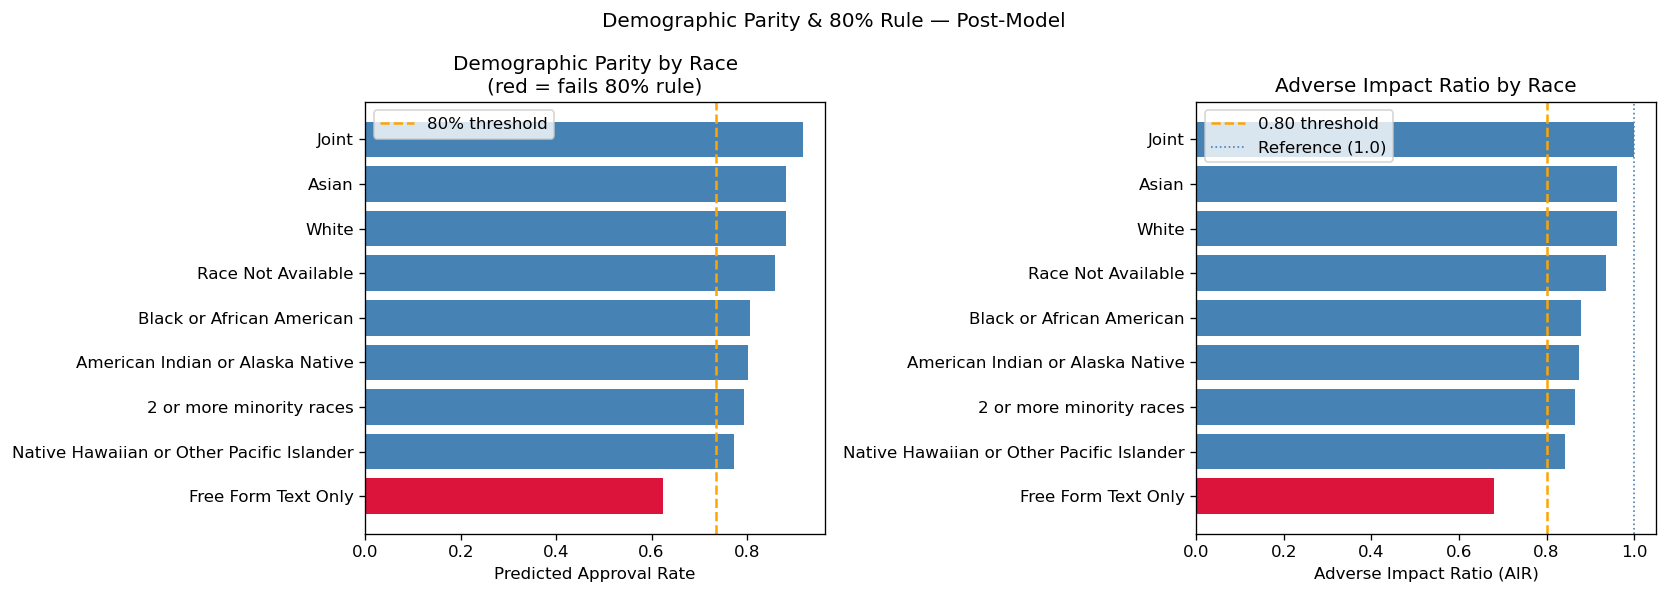

In [8]:
# Visualize: predicted approval rate + AIR by race
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Approval rate
    colors = ['crimson' if f else 'steelblue' for f in race_tbl['fails_80pct']]
    axes[0].barh(race_tbl['group'], race_tbl['pred_rate'], color=colors)
    max_rate = race_tbl['pred_rate'].max()
    axes[0].axvline(max_rate * 0.80, color='orange', linestyle='--',
                   linewidth=1.5, label='80% threshold')
    axes[0].set_xlabel('Predicted Approval Rate')
    axes[0].set_title('Demographic Parity by Race\n(red = fails 80% rule)')
    axes[0].legend()
    axes[0].invert_yaxis()

    # AIR
    axes[1].barh(race_tbl['group'], race_tbl['AIR'], color=colors)
    axes[1].axvline(0.80, color='orange', linestyle='--', linewidth=1.5, label='0.80 threshold')
    axes[1].axvline(1.00, color='steelblue', linestyle=':', linewidth=1.0, label='Reference (1.0)')
    axes[1].set_xlabel('Adverse Impact Ratio (AIR)')
    axes[1].set_title('Adverse Impact Ratio by Race')
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.suptitle('Demographic Parity & 80% Rule — Post-Model', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_demographic_parity.png'))
    plt.show()

## 4. Equalized Odds

Equalized-odds diagnostics show **who absorbs model errors**:
- `TPR` is approval recall: how often actually approvable applicants are approved
- `FNR` is the wrongful-denial rate: how often approvable applicants are denied
- `FPR` is the false-approval rate: how often denied applicants are approved

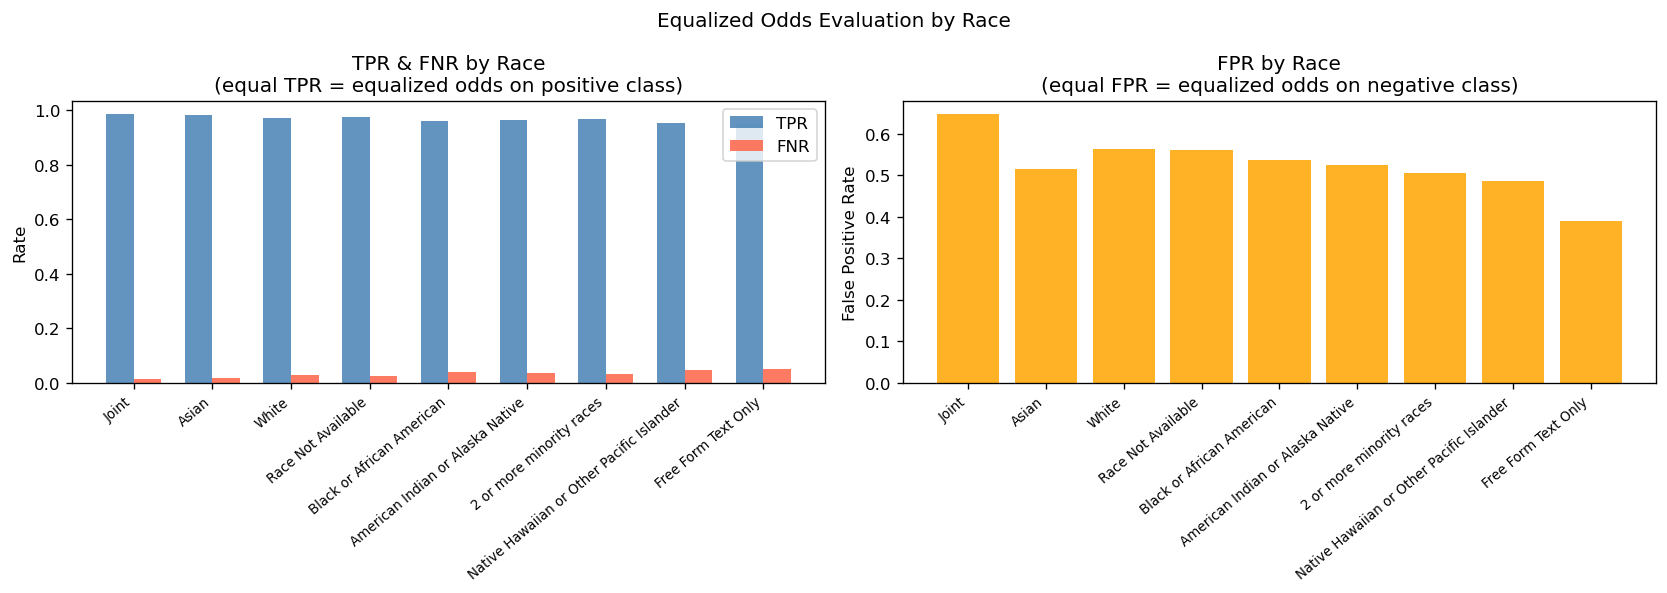

In [9]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(race_tbl))
    width = 0.35

    # TPR / FNR
    axes[0].bar(x - width/2, race_tbl['TPR'], width, label='TPR', color='steelblue', alpha=0.85)
    axes[0].bar(x + width/2, race_tbl['FNR'], width, label='FNR', color='tomato',    alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(race_tbl['group'], rotation=40, ha='right', fontsize=8)
    axes[0].set_ylabel('Rate')
    axes[0].set_title('TPR & FNR by Race\n(equal TPR = equalized odds on positive class)')
    axes[0].legend()

    # FPR
    axes[1].bar(x, race_tbl['FPR'], color='orange', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(race_tbl['group'], rotation=40, ha='right', fontsize=8)
    axes[1].set_ylabel('False Positive Rate')
    axes[1].set_title('FPR by Race\n(equal FPR = equalized odds on negative class)')

    plt.suptitle('Equalized Odds Evaluation by Race', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_equalized_odds.png'))
    plt.show()

## 5. Predictive Parity

Predictive parity requires equal **precision** (PPV) across groups: among those predicted approved, the same fraction should actually be approved regardless of group.

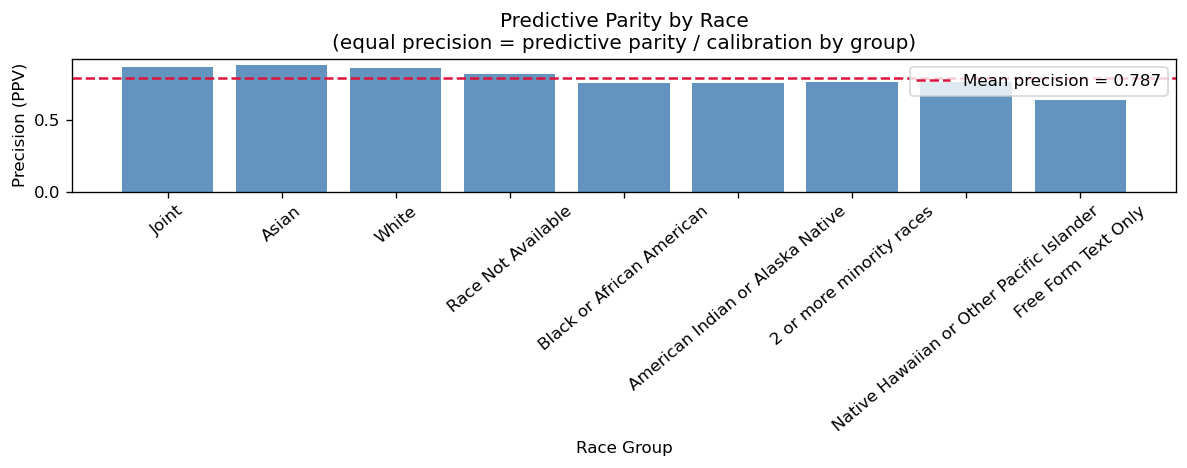

In [10]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(race_tbl['group'], race_tbl['Precision'], color='steelblue', alpha=0.85)
    ax.axhline(race_tbl['Precision'].mean(), color='crimson', linestyle='--',
               linewidth=1.5, label=f'Mean precision = {race_tbl["Precision"].mean():.3f}')
    ax.set_xlabel('Race Group')
    ax.set_ylabel('Precision (PPV)')
    ax.set_title('Predictive Parity by Race\n(equal precision = predictive parity / calibration by group)')
    ax.tick_params(axis='x', rotation=40)
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_predictive_parity.png'))
    plt.show()

## 6. Chouldechova Impossibility Theorem

When base rates differ across groups, a lending model cannot simultaneously equalize every error rate and preserve perfect calibration. That is why the deployment section must document the fairness criterion we choose to prioritize rather than pretending all of them can hold at once.

In [11]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race']

    print('── Chouldechova Impossibility Check ──')
    print('Base rates (actual approval rate) by group:')
    print(race_tbl['base_rate'].to_string())
    print()
    base_rate_range = race_tbl['base_rate'].max() - race_tbl['base_rate'].min()
    fpr_range = race_tbl['FPR'].max() - race_tbl['FPR'].min()
    fnr_range = race_tbl['FNR'].max() - race_tbl['FNR'].min()

    print(f'Base rate spread: {base_rate_range:.4f}')
    print(f'FPR spread:       {fpr_range:.4f}')
    print(f'FNR spread:       {fnr_range:.4f}')
    print()
    print('Governance implication: AIR, FNR, and calibration cannot all be optimized independently when base rates differ.')
    print('Because applicant harm is driven by wrongful denials, FNR is the error-rate metric we interpret most carefully alongside AIR.')

── Chouldechova Impossibility Check ──
Base rates (actual approval rate) by group:
group
Joint                                        0.8029
Asian                                        0.7876
White                                        0.7820
Race Not Available                           0.7218
Black or African American                    0.6346
American Indian or Alaska Native             0.6286
2 or more minority races                     0.6211
Native Hawaiian or Other Pacific Islander    0.6143
Free Form Text Only                          0.4169

Base rate spread: 0.3860
FPR spread:       0.2562
FNR spread:       0.0335

Governance implication: AIR, FNR, and calibration cannot all be optimized independently when base rates differ.
Because applicant harm is driven by wrongful denials, FNR is the error-rate metric we interpret most carefully alongside AIR.


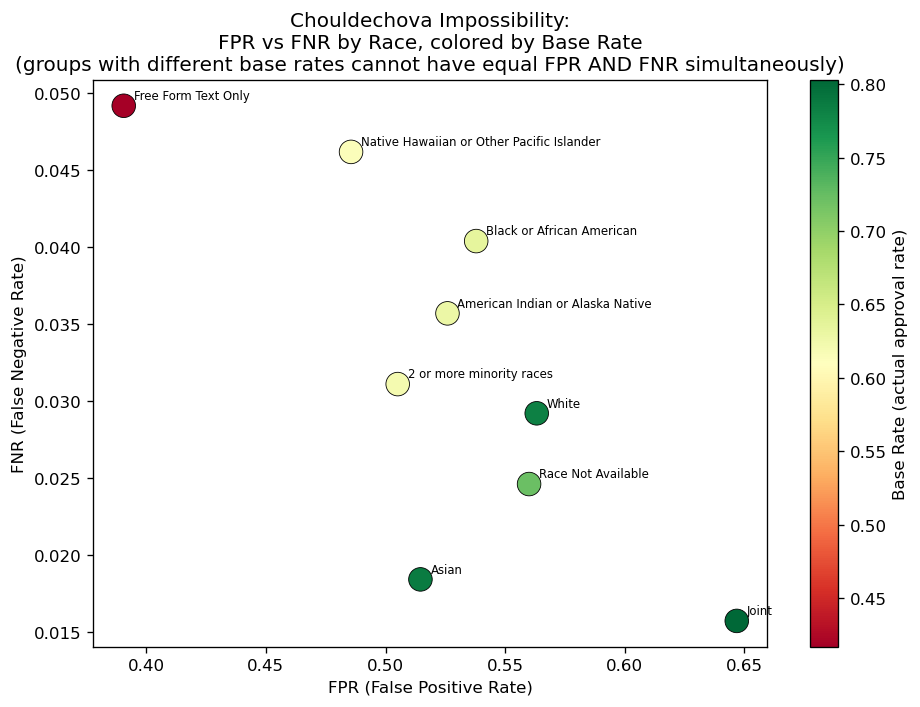

In [12]:
# Visualize the impossibility: FPR vs FNR tradeoff with base rate shown
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        race_tbl['FPR'], race_tbl['FNR'],
        c=race_tbl['base_rate'], cmap='RdYlGn',
        s=200, zorder=5, edgecolors='black', linewidths=0.5
    )
    for _, row in race_tbl.iterrows():
        ax.annotate(row['group'], (row['FPR'], row['FNR']),
                   textcoords='offset points', xytext=(6, 4), fontsize=7)
    plt.colorbar(scatter, ax=ax, label='Base Rate (actual approval rate)')
    ax.set_xlabel('FPR (False Positive Rate)')
    ax.set_ylabel('FNR (False Negative Rate)')
    ax.set_title('Chouldechova Impossibility:\nFPR vs FNR by Race, colored by Base Rate\n'
                '(groups with different base rates cannot have equal FPR AND FNR simultaneously)')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_chouldechova.png'))
    plt.show()

## 7. Mitigation — Threshold Adjustment

Mitigation targets the professor's key legal framing directly: if a racial group falls below the four-fifths rule (`AIR < 0.80`), we lower that group's decision threshold just enough to restore the approval-rate floor where possible. This is a post-processing intervention, so the probability model itself stays unchanged and auditable.

In [13]:
if 'derived_race' in prot_test.columns:
    race_series = prot_test['derived_race'].fillna('Unknown').astype(str)
    pre_tbl = fairness_tables['derived_race'].copy()
    reference_group = pre_tbl['pred_rate'].idxmax()
    reference_rate = float(pre_tbl['pred_rate'].max())
    target_air = 0.80
    target_rate = target_air * reference_rate

    print(f'Reference group: {reference_group}')
    print(f'Reference approval rate: {reference_rate:.4f}')
    print(f'Target approval-rate floor: {target_rate:.4f} (AIR >= {target_air:.2f})')
    print()

    group_thresholds = {}
    policy_rows = []
    for group_name, row in pre_tbl.iterrows():
        if row['AIR'] < target_air:
            thresh = find_threshold_for_target_rate(
                y_prob[race_series == group_name],
                target_rate,
                global_threshold,
            )
            action = 'lowered'
        else:
            thresh = global_threshold
            action = 'unchanged'

        group_thresholds[group_name] = float(thresh)
        policy_rows.append({
            'group': group_name,
            'pre_pred_rate': row['pred_rate'],
            'pre_air': row['AIR'],
            'threshold_used': round(float(thresh), 4),
            'action': action,
        })

    y_pred_mitigated, threshold_vector = apply_threshold_policy(
        y_prob,
        race_series,
        global_threshold,
        group_thresholds,
    )
    post_tbl = group_fairness_metrics(y_test, y_prob, y_pred_mitigated, race_series)

    mitigation_summary = pd.DataFrame(policy_rows).set_index('group')
    mitigation_summary['post_pred_rate'] = post_tbl['pred_rate']
    mitigation_summary['post_air'] = post_tbl['AIR']
    mitigation_summary['pre_fnr'] = pre_tbl['FNR']
    mitigation_summary['post_fnr'] = post_tbl['FNR']
    mitigation_summary['pre_fpr'] = pre_tbl['FPR']
    mitigation_summary['post_fpr'] = post_tbl['FPR']

    print('── Pre-Mitigation ──')
    print(pre_tbl[['pred_rate', 'AIR', 'FPR', 'FNR', 'AUC']].to_string())
    print()
    print('── Post-Mitigation ──')
    print(post_tbl[['pred_rate', 'AIR', 'FPR', 'FNR', 'AUC']].to_string())
    print()
    print('── Mitigation Summary ──')
    print(mitigation_summary.to_string())

    acc_pre = accuracy_score(y_test, y_pred)
    acc_post = accuracy_score(y_test, y_pred_mitigated)
    f1_pre = f1_score(y_test, y_pred)
    f1_post = f1_score(y_test, y_pred_mitigated)
    fnr_gap_pre = float(pre_tbl['FNR'].max() - pre_tbl['FNR'].min())
    fnr_gap_post = float(post_tbl['FNR'].max() - post_tbl['FNR'].min())

    print()
    print(f'Accuracy: {acc_pre:.4f} -> {acc_post:.4f} (Δ={acc_post - acc_pre:+.4f})')
    print(f'Approval-class F1: {f1_pre:.4f} -> {f1_post:.4f} (Δ={f1_post - f1_pre:+.4f})')
    print(f'FNR spread: {fnr_gap_pre:.4f} -> {fnr_gap_post:.4f}')

Reference group: Joint
Reference approval rate: 0.9177
Target approval-rate floor: 0.7342 (AIR >= 0.80)



── Pre-Mitigation ──
                                           pred_rate     AIR     FPR     FNR     AUC
group                                                                               
Joint                                         0.9177  1.0000  0.6468  0.0157  0.8382
Asian                                         0.8824  0.9615  0.5146  0.0184  0.8698
White                                         0.8819  0.9610  0.5632  0.0292  0.8386
Race Not Available                            0.8598  0.9369  0.5600  0.0246  0.8452
Black or African American                     0.8056  0.8778  0.5379  0.0404  0.8310
American Indian or Alaska Native              0.8015  0.8734  0.5259  0.0357  0.8477
2 or more minority races                      0.7931  0.8642  0.5051  0.0311  0.8635
Native Hawaiian or Other Pacific Islander     0.7732  0.8425  0.4856  0.0462  0.8529
Free Form Text Only                           0.6241  0.6801  0.3906  0.0492  0.8717

── Post-Mitigation ──
                     


Accuracy: 0.8433 -> 0.8432 (Δ=-0.0000)
Approval-class F1: 0.9037 -> 0.9037 (Δ=-0.0000)
FNR spread: 0.0335 -> 0.0407


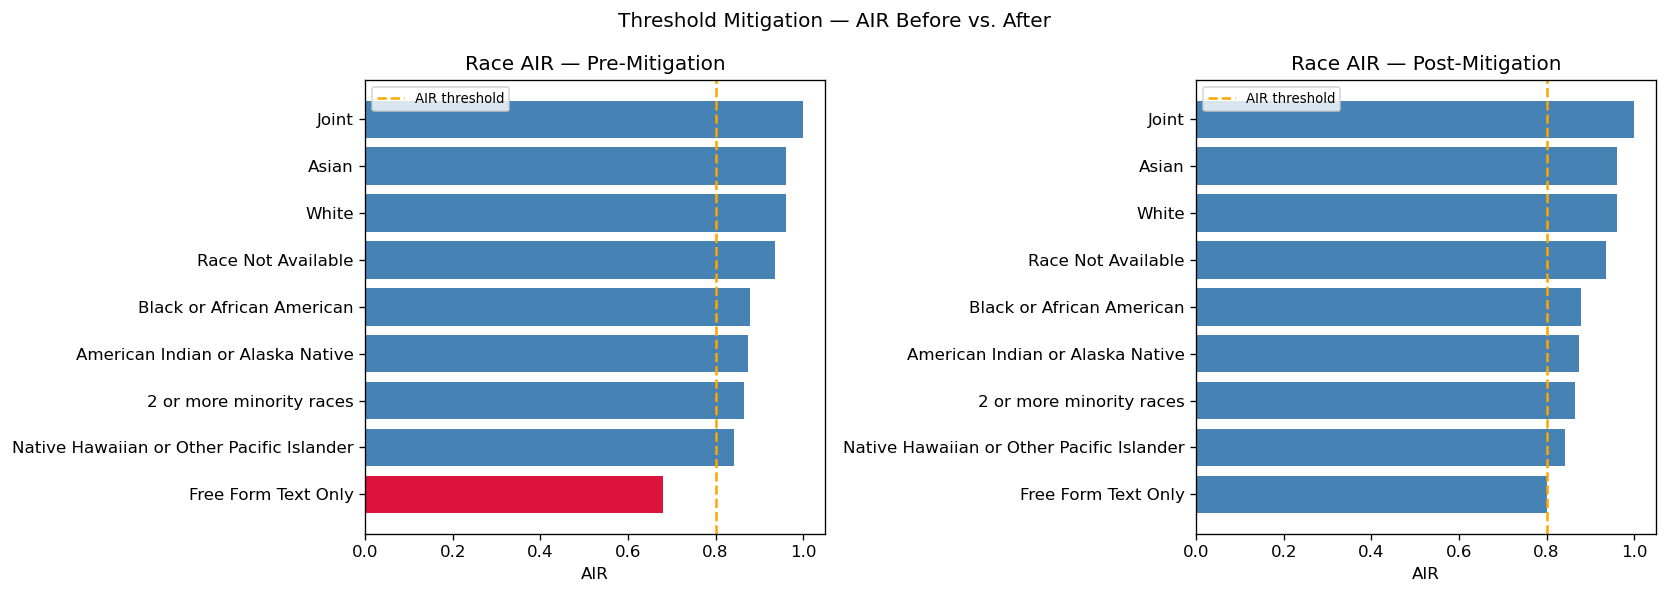

In [14]:
if 'derived_race' in prot_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pre_plot = pre_tbl.reset_index()
    post_plot = post_tbl.reset_index()
    colors_pre = ['crimson' if f else 'steelblue' for f in pre_plot['fails_80pct']]
    colors_post = ['crimson' if f else 'steelblue' for f in post_plot['fails_80pct']]

    axes[0].barh(pre_plot['group'], pre_plot['AIR'], color=colors_pre)
    axes[0].axvline(0.80, color='orange', linestyle='--', linewidth=1.5, label='AIR threshold')
    axes[0].set_xlabel('AIR')
    axes[0].set_title('Race AIR — Pre-Mitigation')
    axes[0].legend(fontsize=8)
    axes[0].invert_yaxis()

    axes[1].barh(post_plot['group'], post_plot['AIR'], color=colors_post)
    axes[1].axvline(0.80, color='orange', linestyle='--', linewidth=1.5, label='AIR threshold')
    axes[1].set_xlabel('AIR')
    axes[1].set_title('Race AIR — Post-Mitigation')
    axes[1].legend(fontsize=8)
    axes[1].invert_yaxis()

    plt.suptitle('Threshold Mitigation — AIR Before vs. After', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_mitigation_air.png'))
    fig.savefig(os.path.join(FIGURES_DIR, '04_mitigation_fpr.png'))
    plt.show()

In [15]:
print('Mitigation comparison figure saved as figures/04_mitigation_air.png.')

Mitigation comparison figure saved as figures/04_mitigation_air.png.


## 8. Residual Risk Summary

Per capstone question 4: *What risks remain after mitigation?*

In [16]:
residual_risks = pd.DataFrame([
    {
        'Risk': 'Proxy discrimination',
        'Trigger Condition': 'DTI and property value can still proxy structural inequality even without direct race features',
        'Affected Group': 'Historically disadvantaged racial groups',
        'Severity': 'High',
        'Mitigation': 'Protected attributes excluded from X; geographic features excluded; SHAP audit performed in NB05',
        'Outcome': 'Direct geographic proxy risk reduced, but legitimate financial features still carry social history',
        'Accepted Residual': 'Soft proxy risk remains and must be documented rather than denied',
    },
    {
        'Risk': 'Sample selection bias',
        'Trigger Condition': 'action_taken 4–8 records are excluded by project design',
        'Affected Group': 'Any group with systematically different withdrawal or incompleteness rates',
        'Severity': 'High',
        'Mitigation': 'Explicitly documented; no safe post-hoc statistical repair without ground-truth outcomes',
        'Outcome': 'The modeling sample is cleaner than the raw HMDA process but not fully representative',
        'Accepted Residual': 'Deployment claims are limited to the filtered approval-vs-denial population',
    },
    {
        'Risk': 'Residual subgroup disparity after mitigation',
        'Trigger Condition': 'Intersectional groups can still fail AIR or absorb higher wrongful-denial rates',
        'Affected Group': 'Race × sex combinations and rare coding groups such as free-form text',
        'Severity': 'Medium',
        'Mitigation': 'Race-based threshold adjustment and explicit intersectional audit',
        'Outcome': 'Primary race table improves, but low-volume and intersectional disparities may remain',
        'Accepted Residual': 'Quarterly intersectional AIR review remains mandatory',
    },
    {
        'Risk': 'Temporal drift',
        'Trigger Condition': 'Macroeconomic conditions, underwriting standards, or applicant mix shift after 2024',
        'Affected Group': 'All applicants',
        'Severity': 'Medium',
        'Mitigation': 'PSI, KS, MMD, and stress testing in NB06',
        'Outcome': 'No material train/test drift detected inside the static 2024 split',
        'Accepted Residual': 'Any real deployment beyond the audited window requires continuous monitoring',
    },
    {
        'Risk': 'Chouldechova trade-off',
        'Trigger Condition': 'Base rates differ substantially across groups',
        'Affected Group': 'Lower-base-rate groups bear some trade-off no matter which criterion is optimized',
        'Severity': 'Structural',
        'Mitigation': 'AIR-focused threshold adjustment with explicit before/after reporting',
        'Outcome': 'AIR can improve without eliminating every FNR or FPR difference',
        'Accepted Residual': 'The project must disclose which fairness criterion was prioritized and why',
    },
    {
        'Risk': 'Feedback loop',
        'Trigger Condition': 'Model-driven denials influence future applicant behavior or retraining data',
        'Affected Group': 'Already disadvantaged groups',
        'Severity': 'High (if deployed)',
        'Mitigation': 'Not solvable offline; requires governance policy',
        'Outcome': 'Not measurable in this static capstone dataset',
        'Accepted Residual': 'Retraining should require a fresh disparity audit before reuse',
    },
])

print('── Residual Risk Register ──')
for _, row in residual_risks.iterrows():
    print(f"\n▸ {row['Risk']}  [{row['Severity']}]")
    print(f"  Trigger:   {row['Trigger Condition']}")
    print(f"  Group:     {row['Affected Group']}")
    print(f"  Mitig:     {row['Mitigation']}")
    print(f"  Outcome:   {row['Outcome']}")
    print(f"  Residual:  {row['Accepted Residual']}")

── Residual Risk Register ──

▸ Proxy discrimination  [High]
  Trigger:   DTI and property value can still proxy structural inequality even without direct race features
  Group:     Historically disadvantaged racial groups
  Mitig:     Protected attributes excluded from X; geographic features excluded; SHAP audit performed in NB05
  Outcome:   Direct geographic proxy risk reduced, but legitimate financial features still carry social history
  Residual:  Soft proxy risk remains and must be documented rather than denied

▸ Sample selection bias  [High]
  Trigger:   action_taken 4–8 records are excluded by project design
  Group:     Any group with systematically different withdrawal or incompleteness rates
  Mitig:     Explicitly documented; no safe post-hoc statistical repair without ground-truth outcomes
  Outcome:   The modeling sample is cleaner than the raw HMDA process but not fully representative
  Residual:  Deployment claims are limited to the filtered approval-vs-denial populat

In [17]:
residual_risks.to_csv(os.path.join(TABLES_DIR, '04_residual_risks.csv'), index=False)
print(f'Saved → {os.path.join(TABLES_DIR, "04_residual_risks.csv")}')

triggers = pd.DataFrame([
    {
        'Trigger Condition': 'AIR drops below 0.80 for any primary racial group',
        'Monitoring Mechanism': 'Quarterly AIR audit on deployment decisions',
        'Required Action': 'Re-run threshold calibration and review deployment conditions',
    },
    {
        'Trigger Condition': 'FNR spread across racial groups exceeds 0.05',
        'Monitoring Mechanism': 'Quarterly subgroup error review',
        'Required Action': 'Pause deployment review until applicant-harm gap is explained or mitigated',
    },
    {
        'Trigger Condition': 'PSI exceeds 0.10 on income, DTI, or property value',
        'Monitoring Mechanism': 'Monthly leading-indicator monitoring',
        'Required Action': 'Investigate drift and prepare retraining package',
    },
    {
        'Trigger Condition': 'Overall AUC drops below 0.80 or approval share shifts materially',
        'Monitoring Mechanism': 'Monthly model scorecard',
        'Required Action': 'Model review and recalibration before continued use',
    },
])
triggers.to_csv(os.path.join(TABLES_DIR, '04_deployment_triggers.csv'), index=False)
print(f'Saved → {os.path.join(TABLES_DIR, "04_deployment_triggers.csv")}')

for col, tbl in fairness_tables.items():
    tbl.to_csv(os.path.join(TABLES_DIR, f'04_fairness_{col}.csv'))
    print(f'Saved → {os.path.join(TABLES_DIR, f"04_fairness_{col}.csv")}')

post_tbl.to_csv(os.path.join(TABLES_DIR, '04_fairness_derived_race_post_mitigation.csv'))
mitigation_summary.to_csv(os.path.join(TABLES_DIR, '04_mitigation_summary.csv'))
print(f'Saved → {os.path.join(TABLES_DIR, "04_fairness_derived_race_post_mitigation.csv")}')
print(f'Saved → {os.path.join(TABLES_DIR, "04_mitigation_summary.csv")}')

threshold_meta = {
    'policy_name': 'air_floor_threshold_adjustment',
    'global_threshold': float(global_threshold),
    'reference_group': reference_group,
    'reference_pred_rate': float(reference_rate),
    'target_air_floor': target_air,
    'group_thresholds': {k: float(v) for k, v in group_thresholds.items()},
}
with open(os.path.join(BASE_DIR, 'threshold_meta.json'), 'w') as f:
    json.dump(threshold_meta, f, indent=2)
print('Saved → threshold_meta.json')
print(json.dumps(threshold_meta, indent=2))

presentation_rows = [
    {
        'Section': 'Objective',
        'Metric': 'Approval-class F1',
        'Value': round(global_threshold, 4),
        'Interpretation': 'Global deployment threshold used before group-specific mitigation',
    },
    {
        'Section': 'Fairness Before',
        'Metric': 'Race groups failing AIR < 0.80',
        'Value': int(pre_tbl['fails_80pct'].sum()),
        'Interpretation': ', '.join(pre_tbl[pre_tbl['fails_80pct']].index.tolist()) or 'None',
    },
    {
        'Section': 'Fairness After',
        'Metric': 'Race groups failing AIR < 0.80',
        'Value': int(post_tbl['fails_80pct'].sum()),
        'Interpretation': ', '.join(post_tbl[post_tbl['fails_80pct']].index.tolist()) or 'None',
    },
    {
        'Section': 'Residual Risk',
        'Metric': 'Largest race-level FNR after mitigation',
        'Value': round(float(post_tbl['FNR'].max()), 4),
        'Interpretation': post_tbl['FNR'].idxmax(),
    },
]
pd.DataFrame(presentation_rows).to_csv(os.path.join(TABLES_DIR, '00_presentation_fairness_summary.csv'), index=False)
print(f'Saved → {os.path.join(TABLES_DIR, "00_presentation_fairness_summary.csv")}')

Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_residual_risks.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_deployment_triggers.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_fairness_derived_race.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_fairness_derived_sex.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_fairness_derived_ethnicity.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_fairness_applicant_age.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_fairness_derived_race_post_mitigation.csv
Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/04_mitigation_summary.csv
Saved → threshold_meta.json
{
  "policy_name": "air_floor_thres

## 9. Who Benefits, Who Bears Cost

In [18]:
print('══ Optimization Objective Stakeholder Analysis ══')
print('OPTIMIZATION OBJECTIVE:')
print(f'  Predict approval (label=1) and maximize approval-class F1 at threshold {global_threshold:.4f}.')
print('  Applicant harm is monitored through FNR because false negatives are wrongful denials.')
print()
print('WHO BENEFITS:')
print('  Applicants with approvable profiles: fewer missed approvals at the tuned threshold')
print('  Lenders: transparent, reproducible scorecard with explicit monitoring triggers')
print('  Reviewers and regulators: documented trade-offs instead of unsupported fairness claims')
print()
print('WHO BEARS THE COST IF THE MODEL IS WRONG:')
print('  False negatives: eligible applicants denied credit access')
print('  False positives: denied applicants approved into higher lender credit risk')
print()
print('══ Deployment Recommendation Summary ══')
pre_fail = pre_tbl[pre_tbl['fails_80pct']].index.tolist()
post_fail = post_tbl[post_tbl['fails_80pct']].index.tolist()
print(f'Pre-mitigation AIR failures:  {pre_fail if pre_fail else "None"}')
print(f'Post-mitigation AIR failures: {post_fail if post_fail else "None"}')
print()
if not post_fail:
    verdict = 'Conditionally defensible — only with ongoing monitoring, documented thresholds, and quarterly fairness review.'
else:
    verdict = 'Not fully defensible without additional mitigation for the remaining AIR-failing groups.'
print(f'VERDICT: {verdict}')
print('GitHub repo role: the repository is the audit record, not just a submission folder.')

══ Optimization Objective Stakeholder Analysis ══
OPTIMIZATION OBJECTIVE:
  Predict approval (label=1) and maximize approval-class F1 at threshold 0.7289.
  Applicant harm is monitored through FNR because false negatives are wrongful denials.

WHO BENEFITS:
  Applicants with approvable profiles: fewer missed approvals at the tuned threshold
  Lenders: transparent, reproducible scorecard with explicit monitoring triggers
  Reviewers and regulators: documented trade-offs instead of unsupported fairness claims

WHO BEARS THE COST IF THE MODEL IS WRONG:
  False negatives: eligible applicants denied credit access
  False positives: denied applicants approved into higher lender credit risk

══ Deployment Recommendation Summary ══
Pre-mitigation AIR failures:  ['Free Form Text Only']
Post-mitigation AIR failures: None

VERDICT: Conditionally defensible — only with ongoing monitoring, documented thresholds, and quarterly fairness review.
GitHub repo role: the repository is the audit record, no